# Notebook 01: Exploratory Data Analysis (EDA)

This notebook loads the Telco Customer Churn dataset and performs exploratory data analysis to understand customer behavior, dataset distributions, and key drivers of churn.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load and Inspect the Dataset

We load the dataset and display basic statistics: shape, data types, and null values.

In [2]:
df = pd.read_csv('../data/telco_churn.csv')
print(f'Dataset Shape: {df.shape}')
print('\nDataset Columns and Types:')
print(df.dtypes)
print('\nNull Values Count:')
print(df.isnull().sum())

Dataset Shape: (7043, 21)

Dataset Columns and Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Null Values Count:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies 

## 2. Visualize Churn Distribution

We look at the proportion of customers who churned vs. those who stayed.

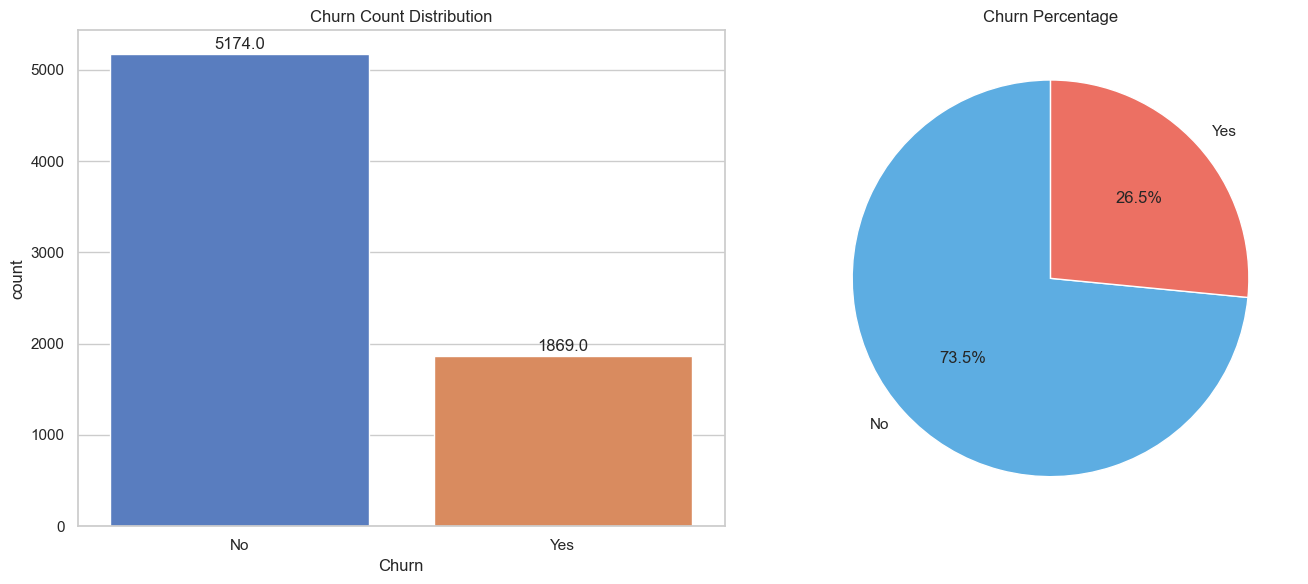

In [3]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar Chart
sns.countplot(data=df, x='Churn', ax=axes[0], hue='Churn', legend=False)
axes[0].set_title('Churn Count Distribution')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height() + 50), ha='center')

# Pie Chart
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#5dade2', '#ec7063'])
axes[1].set_title('Churn Percentage')

plt.tight_layout()
plt.show()

## 3. Churn by Contract Type

We analyze the relationship between contract types and churn rate.

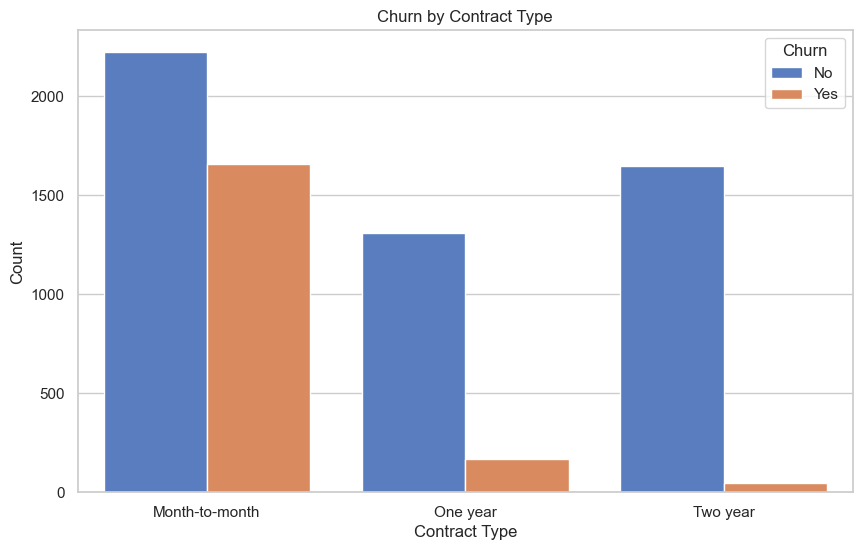

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [4]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.ylabel('Count')
plt.xlabel('Contract Type')
plt.show()

# Cross-tabulation percentage
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

## 4. Churn by Customer Tenure

We analyze if newer customers (lower tenure) have a higher propensity to churn.

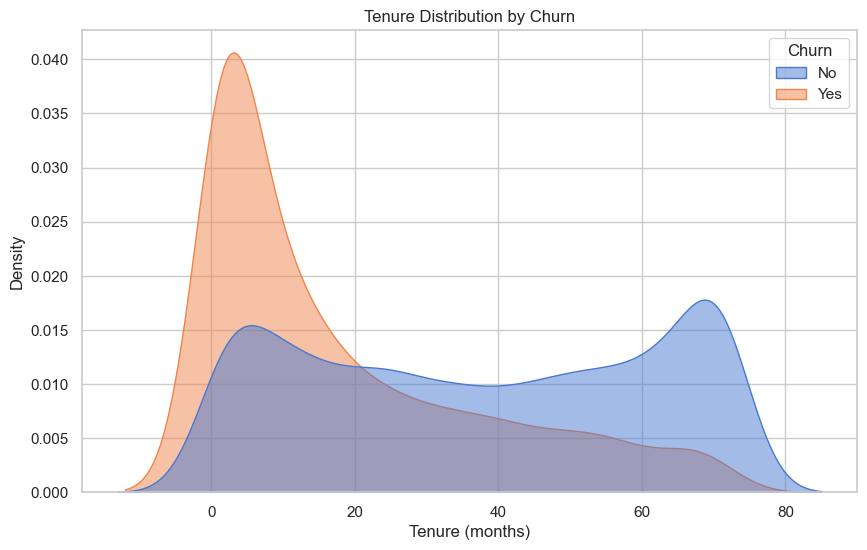

In [5]:
fig, ax = plt.subplots()
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, alpha=0.5, ax=ax)
ax.set_title('Tenure Distribution by Churn')
ax.set_xlabel('Tenure (months)')
plt.show()

## 5. Churn by Monthly Charges

We inspect if customers with higher monthly bills tend to churn more.

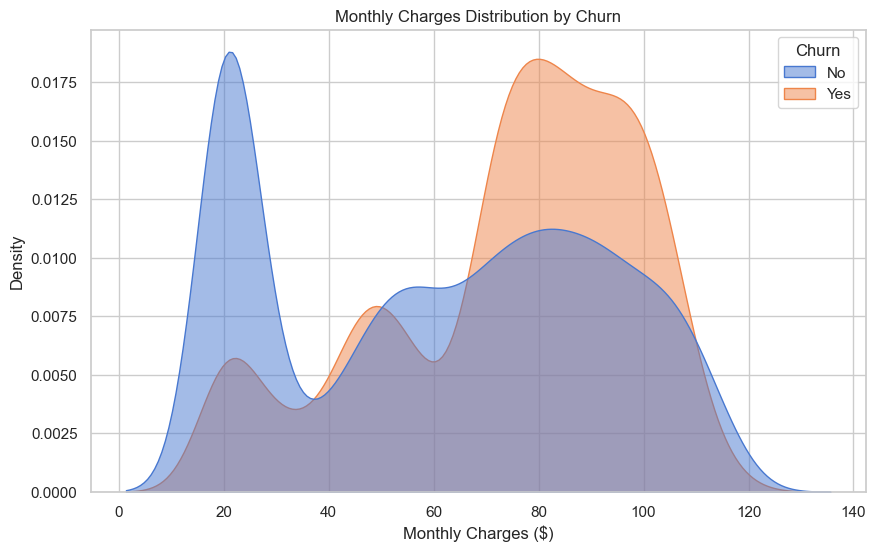

In [6]:
fig, ax = plt.subplots()
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, alpha=0.5, ax=ax)
ax.set_title('Monthly Charges Distribution by Churn')
ax.set_xlabel('Monthly Charges ($)')
plt.show()

## 6. Churn by Internet Service Type

We analyze how internet connection medium correlates with churn.

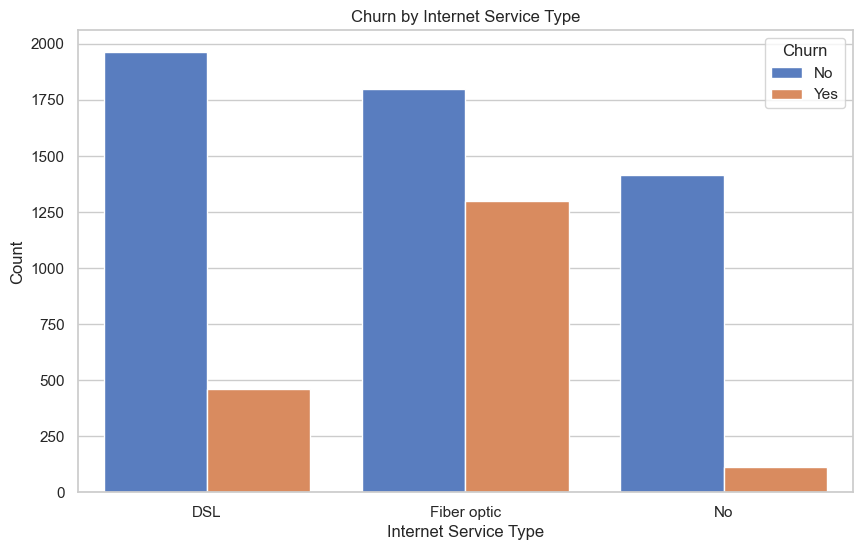

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [7]:
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service Type')
plt.ylabel('Count')
plt.xlabel('Internet Service Type')
plt.show()

pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

## 7. Correlation Heatmap

We convert TotalCharges to numeric, map Churn to binary, and plot the correlation heatmap.

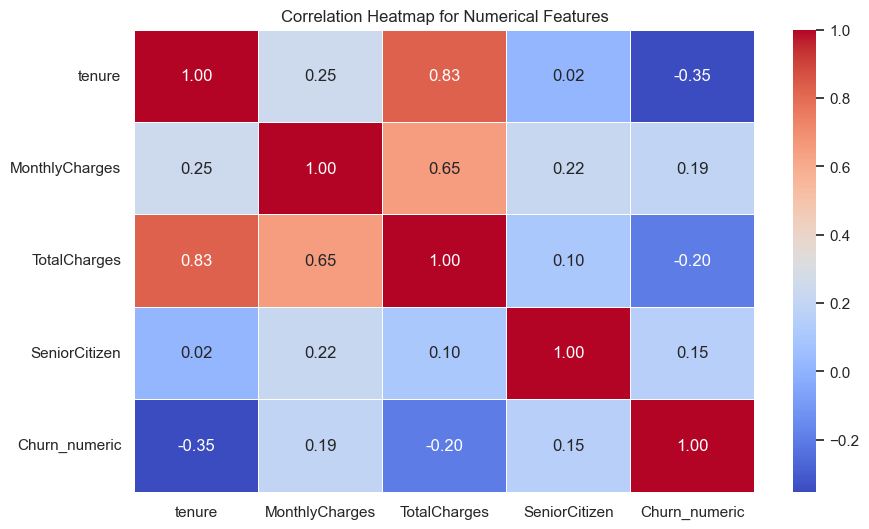

In [8]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Select numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_numeric']
corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Numerical Features')
plt.show()

## 8. Summary of Key Insights from EDA
1. **Churn Imbalance**: ~26.5% of customers churn, showing that the dataset is imbalanced.
2. **Contract Type**: Month-to-month contracts exhibit highly elevated churn rates (~42.7%) compared to one-year (~11.3%) and two-year (~2.8%) contracts.
3. **Tenure**: Newly acquired customers (low tenure, <10 months) are at a much higher risk of churning.
4. **Charges**: Higher monthly charges correlate with higher churn rates.
5. **Internet Service**: Fiber optic subscribers have a disproportionately high churn rate (~41.9%) compared to DSL (~19.0%) and no internet service (~7.4%).